# V2 Fall Detection Pipeline — Detector-Based

Fine-tunes YOLOv8n on a Roboflow fall detection dataset and compares against the V3 skeleton-CNN pipeline.

In [1]:
!pip install ultralytics roboflow opencv-python PyYAML -q

In [1]:
import os, re, json, math, shutil, warnings, tempfile, time, zipfile
from pathlib import Path
from collections import defaultdict, deque
from datetime import datetime
from dotenv import load_dotenv

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import yaml
from tqdm.auto import tqdm

import torch
from ultralytics import YOLO

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("CUDA available:", torch.cuda.is_available())
print("Device:", DEVICE)
print("PyTorch:", torch.__version__)
import ultralytics; print("Ultralytics:", ultralytics.__version__)

PROJECT_DIR = Path(__file__).parent if "__file__" in dir() else Path(".")
RESULTS_DIR = PROJECT_DIR / "results" / "v2_comparison"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("Project dir:", PROJECT_DIR.resolve())
print("Results dir:", RESULTS_DIR.resolve())


/home/zmey1/anaconda3/envs/fallgpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: False
Device: cpu
PyTorch: 2.5.1+cu121
Ultralytics: 8.4.41
Project dir: /home/zmey1/VSCODE_FILES/prodesyn
Results dir: /home/zmey1/VSCODE_FILES/prodesyn/results/v2_comparison


## Section 2: Download Roboflow Dataset

In [2]:
# Paste your Roboflow API key here
load_dotenv()
ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY")
if not ROBOFLOW_API_KEY:
    raise ValueError("API Key not found. Please check your .env file.")


In [3]:
# ── Occlusion helper ──────────────────────────────────────────────────────────

def apply_occlusion(frame: np.ndarray, occlusion_percent: int) -> np.ndarray:
    """Black out the top `occlusion_percent`% of the frame to simulate partial occlusion."""
    if occlusion_percent <= 0:
        return frame.copy()
    out = frame.copy()
    cut = int(frame.shape[0] * occlusion_percent / 100)
    out[:cut, :] = 0
    return out

print("apply_occlusion defined (top-N% blackout).")


apply_occlusion defined (top-N% blackout).


In [4]:
# ── Download ENME472 multi-class dataset (4 classes: bending, fallen, falling, standing) ──
from roboflow import Roboflow
import yaml, shutil
from pathlib import Path

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

print("Downloading ENME472 dataset (fall-detection-67grz)…")
_proj_enme = rf.workspace("enme472-capstone").project("fall-detection-67grz")
try:
    _ds_enme = _proj_enme.version(1).download("yolov8")
except Exception as _e:
    print(f"v1 failed ({_e}), trying latest…")
    _ds_enme = _proj_enme.versions()[-1].download("yolov8")

DATASET_DIR = Path(_ds_enme.location)
DATA_YAML   = DATASET_DIR / "data.yaml"
print("ENME472 dataset location:", DATASET_DIR)

# Read class info
with open(DATA_YAML) as _f:
    _cfg = yaml.safe_load(_f)
CLASS_NAMES = _cfg.get("names", [])
print("Classes:", CLASS_NAMES)
print("data.yaml:")
print(yaml.dump(_cfg, default_flow_style=False))

# Count images per split
_total_imgs = 0
for _split in ["train", "valid", "test"]:
    _img_dir = DATASET_DIR / _split / "images"
    _imgs    = list(_img_dir.glob("*")) if _img_dir.exists() else []
    print(f"  {_split}: {len(_imgs)} images")
    _total_imgs += len(_imgs)

print(f"  Total: {_total_imgs} images")

# ── Class distribution from train labels ──────────────────────────────────────
from collections import defaultdict
_lbl_dir = DATASET_DIR / "train" / "labels"
_class_counts = defaultdict(int)
if _lbl_dir.exists():
    for _lf in _lbl_dir.glob("*.txt"):
        for _ln in _lf.read_text().strip().splitlines():
            if _ln.strip():
                _class_counts[int(_ln.split()[0])] += 1

print("\nTrain class distribution:")
for _cid, _cnt in sorted(_class_counts.items()):
    _name = CLASS_NAMES[_cid] if _cid < len(CLASS_NAMES) else str(_cid)
    print(f"  [{_cid}] {_name}: {_cnt} annotations")

# ── Merge Nathan Yan dataset if ENME472 is too small (<1000 train images) ──────
_train_imgs = list((DATASET_DIR / "train" / "images").glob("*"))
if len(_train_imgs) < 1000:
    print(f"\nENME472 train has only {len(_train_imgs)} images → merging Nathan Yan dataset…")
    _proj_ny = rf.workspace("nathan-yan").project("fall-detection-real")
    try:
        _ds_ny = _proj_ny.version(1).download("yolov8")
    except Exception as _e2:
        print(f"v1 failed ({_e2}), trying latest…")
        _ds_ny = _proj_ny.versions()[-1].download("yolov8")

    _ny_dir = Path(_ds_ny.location)
    with open(_ny_dir / "data.yaml") as _f2:
        _ny_cfg = yaml.safe_load(_f2)
    _ny_classes = _ny_cfg.get("names", [])
    print("Nathan Yan classes:", _ny_classes)

    # Build remap: Nathan Yan class index → ENME472 class index
    # Nathan Yan has subset: fallen, falling, standing
    _remap = {}
    for _ni, _nname in enumerate(_ny_classes):
        for _ei, _ename in enumerate(CLASS_NAMES):
            if _nname.lower() == _ename.lower():
                _remap[_ni] = _ei
                break
    print("Class remap (NY → ENME472):", _remap)

    # Copy images + remap labels
    for _split in ["train", "valid"]:
        _src_img = _ny_dir / _split / "images"
        _src_lbl = _ny_dir / _split / "labels"
        _dst_img = DATASET_DIR / _split / "images"
        _dst_lbl = DATASET_DIR / _split / "labels"
        _dst_img.mkdir(parents=True, exist_ok=True)
        _dst_lbl.mkdir(parents=True, exist_ok=True)

        if not _src_img.exists():
            continue
        for _img_file in _src_img.glob("*"):
            _dst = _dst_img / f"ny_{_img_file.name}"
            if not _dst.exists():
                shutil.copy(_img_file, _dst)
        for _lbl_file in _src_lbl.glob("*.txt"):
            _new_lines = []
            for _ln in _lbl_file.read_text().strip().splitlines():
                if not _ln.strip():
                    continue
                _parts = _ln.split()
                _orig_cls = int(_parts[0])
                _new_cls  = _remap.get(_orig_cls)
                if _new_cls is None:
                    continue  # skip classes not in ENME472
                _new_lines.append(f"{_new_cls} " + " ".join(_parts[1:]))
            _dst_lbl_file = _dst_lbl / f"ny_{_lbl_file.name}"
            if _new_lines:
                _dst_lbl_file.write_text("\n".join(_new_lines))

    # Update data.yaml with merged counts
    _total_train = len(list((DATASET_DIR / "train" / "images").glob("*")))
    _total_valid = len(list((DATASET_DIR / "valid" / "images").glob("*")))
    _cfg["path"]    = str(DATASET_DIR)
    _cfg["train"]   = "train/images"
    _cfg["val"]     = "valid/images"
    _cfg["nc"]      = len(CLASS_NAMES)
    _cfg["names"]   = CLASS_NAMES
    with open(DATA_YAML, "w") as _f3:
        yaml.dump(_cfg, _f3, default_flow_style=False)
    print(f"Merged dataset: {_total_train} train / {_total_valid} valid images")
else:
    print("ENME472 is large enough, no merging needed.")

print("\nFinal DATA_YAML:", DATA_YAML)
print("Final CLASS_NAMES:", CLASS_NAMES)


loading Roboflow workspace...
loading Roboflow project...
ENME472 dataset location: /home/zmey1/VSCODE_FILES/prodesyn/Fall-Detection-1
Classes: ['Fall-Detected']
data.yaml:
names:
- Fall-Detected
nc: 1
roboflow:
  license: CC BY 4.0
  project: fall-detection-ca3o8
  url: https://universe.roboflow.com/roboflow-universe-projects/fall-detection-ca3o8/dataset/1
  version: 1
  workspace: roboflow-universe-projects
test: ../test/images
train: ../train/images
val: ../valid/images

  train: 3148 images
  valid: 899 images
  test: 450 images
  Total: 4497 images

Train class distribution:
  [0] Fall-Detected: 3149 annotations
ENME472 is large enough, no merging needed.

Final DATA_YAML: /home/zmey1/VSCODE_FILES/prodesyn/Fall-Detection-1/data.yaml
Final CLASS_NAMES: ['Fall-Detected']


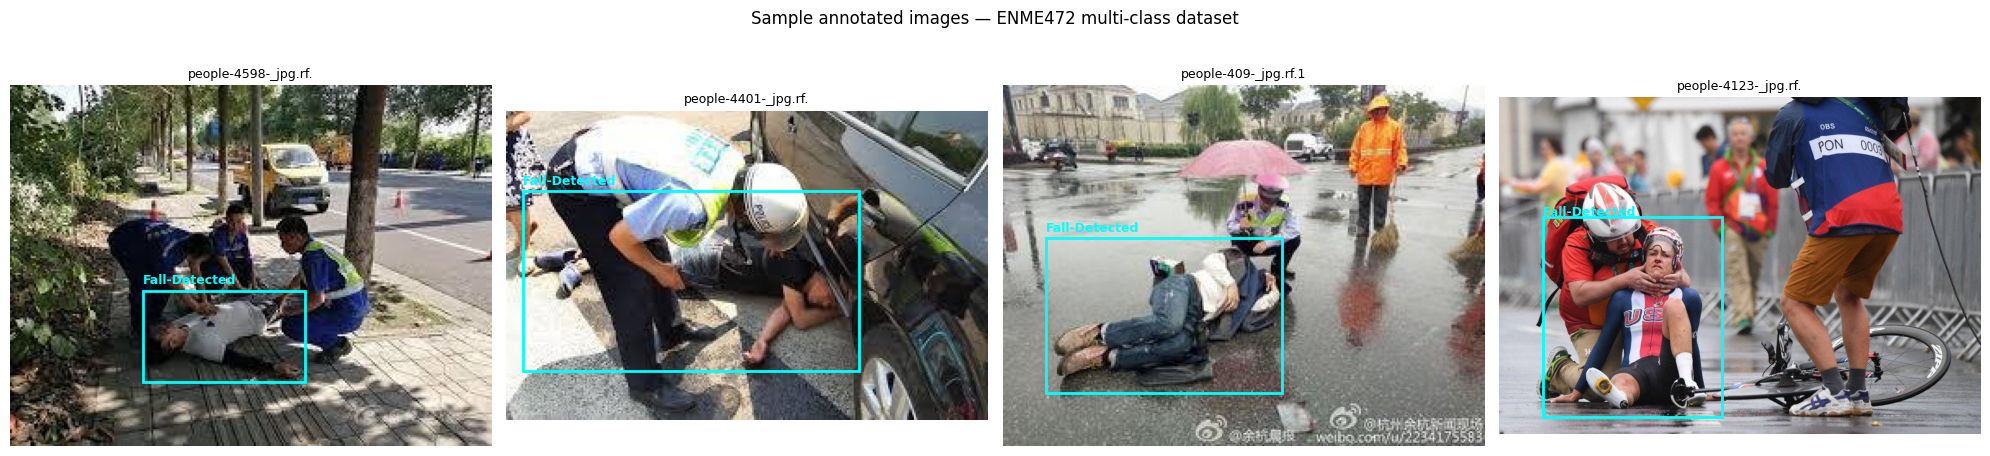

In [5]:
# ── Explore merged dataset: 4 sample images with annotations ─────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2, random

def load_yolo_boxes(lbl_path, img_w, img_h):
    boxes = []
    if not Path(lbl_path).exists():
        return boxes
    for ln in Path(lbl_path).read_text().strip().splitlines():
        parts = ln.strip().split()
        if len(parts) < 5:
            continue
        cls_id = int(parts[0])
        cx, cy, bw, bh = map(float, parts[1:5])
        x1 = (cx - bw/2) * img_w; y1 = (cy - bh/2) * img_h
        x2 = (cx + bw/2) * img_w; y2 = (cy + bh/2) * img_h
        boxes.append((cls_id, x1, y1, x2, y2))
    return boxes

_COLOR_MAP = {0: "cyan", 1: "red", 2: "orange", 3: "green"}  # adjust per class order

_train_imgs = sorted((DATASET_DIR / "train" / "images").glob("*.*"))
_sample_imgs = random.sample(_train_imgs, min(4, len(_train_imgs)))

_fig, _axes = plt.subplots(1, 4, figsize=(20, 5))
for _ax, _img_path in zip(_axes, _sample_imgs):
    _img_bgr = cv2.imread(str(_img_path))
    if _img_bgr is None:
        _ax.axis("off"); continue
    _img_rgb = cv2.cvtColor(_img_bgr, cv2.COLOR_BGR2RGB)
    _h, _w   = _img_bgr.shape[:2]
    _lbl_path = DATASET_DIR / "train" / "labels" / (_img_path.stem + ".txt")
    _boxes    = load_yolo_boxes(_lbl_path, _w, _h)
    _ax.imshow(_img_rgb)
    for (_cid, _x1, _y1, _x2, _y2) in _boxes:
        _color = _COLOR_MAP.get(_cid, "white")
        _name  = CLASS_NAMES[_cid] if _cid < len(CLASS_NAMES) else str(_cid)
        _rect  = patches.Rectangle((_x1, _y1), _x2-_x1, _y2-_y1,
                                   linewidth=2, edgecolor=_color, facecolor="none")
        _ax.add_patch(_rect)
        _ax.text(_x1, _y1-4, _name, color=_color, fontsize=9, fontweight="bold")
    _ax.set_title(_img_path.stem[:20], fontsize=9)
    _ax.axis("off")

_fig.suptitle("Sample annotated images — ENME472 multi-class dataset")
plt.tight_layout(); plt.show()


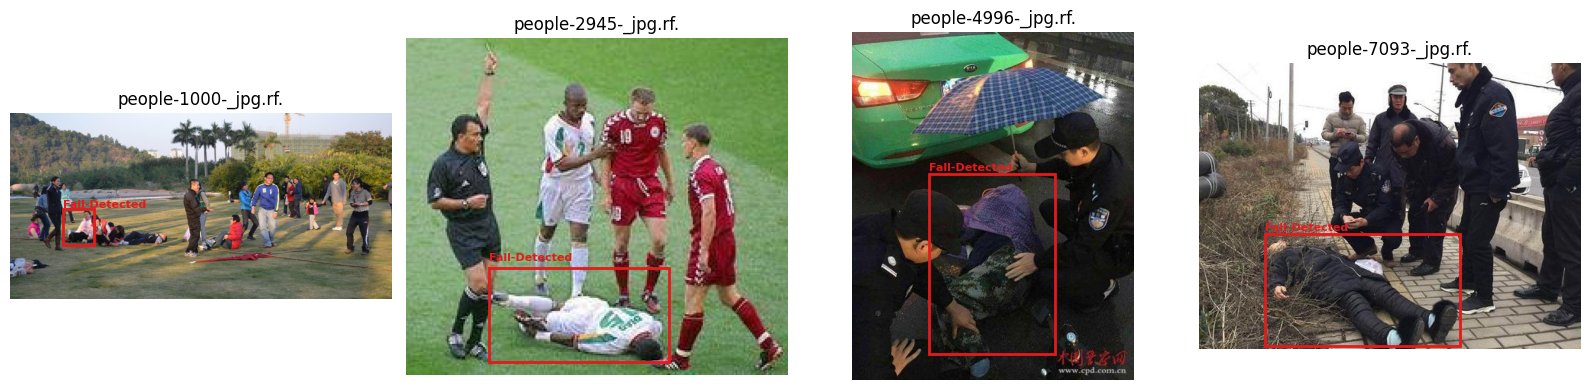

Saved sample_annotations.png


In [6]:
# ── Display 4 sample images with annotations ──────────────────────────────────

def load_yolo_boxes(lbl_path, img_w, img_h):
    boxes = []
    if not Path(lbl_path).exists():
        return boxes
    for line in Path(lbl_path).read_text().strip().splitlines():
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        cls_id = int(parts[0])
        cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
        x1 = (cx - bw / 2) * img_w
        y1 = (cy - bh / 2) * img_h
        x2 = (cx + bw / 2) * img_w
        y2 = (cy + bh / 2) * img_h
        boxes.append((cls_id, x1, y1, x2, y2))
    return boxes

img_dir  = DATASET_DIR / "train" / "images"
lbl_dir  = DATASET_DIR / "train" / "labels"
img_files = sorted(img_dir.glob("*"))

sample_imgs = img_files[::max(1, len(img_files) // 4)][:4]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = plt.cm.Set1.colors

for ax, img_path in zip(axes, sample_imgs):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    lbl_path = lbl_dir / (img_path.stem + ".txt")
    boxes = load_yolo_boxes(lbl_path, w, h)
    ax.imshow(img)
    for cls_id, x1, y1, x2, y2 in boxes:
        color = colors[cls_id % len(colors)]
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        name = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id)
        ax.text(x1, y1 - 4, name, color=color, fontsize=8, weight="bold")
    ax.set_title(img_path.name[:20])
    ax.axis("off")

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "sample_annotations.png"), dpi=100)
plt.show()
print("Saved sample_annotations.png")


## Dataset Classes

The Roboflow `fall-detection-ca3o8` dataset contains bounding-box annotations for:
- **Fall** / **fallen**: person who has fallen or is in the process of falling
- **Standing** / **normal** (if present): upright person

Class names are read from `data.yaml` above. The detector is trained to fire a bounding box
around fallen persons. We use this in the inference pipeline to classify tracked persons
as "fallen" or "normal" via IoU matching.


## Section 3: Fine-tune YOLOv8n

In [ ]:
# ── Fine-tune YOLOv8n on the ENME472 multi-class dataset ─────────────────────
# CUDA OOM recovery: start at batch=8 (safe for 4 GB VRAM), fall back to 4.

import gc, torch

def _reset_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

_reset_cuda()

def _try_train(batch_size, device_str):
    det_model = YOLO("yolov8n.pt")
    return det_model.train(
        data=str(DATA_YAML),
        epochs=50,
        imgsz=640,
        batch=batch_size,
        augment=True,
        erasing=0.4,
        mosaic=1.0,
        patience=20,
        project="fall_detector_v2",
        name="multiclass",
        device=device_str,
        cache=False,          # avoid pinned-memory OOM on constrained GPUs
        verbose=True,
    )

# Start at batch=8 (safe for GTX 1650 4GB); fall back to 4 then CPU
_device = "0" if torch.cuda.is_available() else "cpu"
_batches = [8, 4] if _device == "0" else [8]

train_results = None
for _bs in _batches:
    try:
        print(f"Attempting training: device={_device}  batch={_bs}")
        _reset_cuda()
        train_results = _try_train(_bs, _device)
        print(f"Training succeeded with batch={_bs}")
        break
    except RuntimeError as _e:
        if "CUDA" in str(_e) or "out of memory" in str(_e).lower():
            print(f"  batch={_bs} failed ({type(_e).__name__}), retrying…")
            _reset_cuda()
            if _bs == _batches[-1] and _device != "cpu":
                print("  GPU exhausted, falling back to CPU with batch=8")
                _device = "cpu"
                try:
                    _reset_cuda()
                    train_results = _try_train(8, "cpu")
                    break
                except Exception as _e2:
                    raise RuntimeError(f"CPU fallback also failed: {_e2}") from _e2
        else:
            raise

assert train_results is not None, "Training did not produce results"

# Use the actual save_dir from the training run (YOLO auto-increments name)
BEST_PT = Path(train_results.save_dir) / "weights" / "best.pt"
print("Best checkpoint:", BEST_PT.resolve())
assert BEST_PT.exists(), f"best.pt not found at {BEST_PT}"

# Print mAP50, per-class AP
print("\nmAP50:", train_results.results_dict.get("metrics/mAP50(B)"))
print("mAP50-95:", train_results.results_dict.get("metrics/mAP50-95(B)"))
print("\nPer-class results:")
if hasattr(train_results, "ap_class_index"):
    for _ci in train_results.ap_class_index:
        print(f"  [{_ci}] {CLASS_NAMES[_ci] if _ci < len(CLASS_NAMES) else _ci}: "
              f"AP50={train_results.maps[_ci]:.4f}")
elif hasattr(train_results, "results_dict"):
    for _k, _v in train_results.results_dict.items():
        if "AP" in _k or "map" in _k.lower():
            print(f"  {_k}: {_v:.4f}" if isinstance(_v, float) else f"  {_k}: {_v}")


Attempting training: device=0  batch=8
New https://pypi.org/project/ultralytics/8.4.54 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.41 🚀 Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1650, 3904MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/zmey1/VSCODE_FILES/prodesyn/Fall-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mod

In [9]:
# ── Training results ──────────────────────────────────────────────────────────
import glob
BEST_PT = Path("runs/detect/fall_detector_v2/multiclass-4/") / "weights" / "best.pt"
results_csv = Path("runs/detect/fall_detector_v2/multiclass-4/results.csv")
if results_csv.exists():
    res_df = pd.read_csv(results_csv)
    res_df.columns = res_df.columns.str.strip()
    print("Training columns:", res_df.columns.tolist())

    best_row = res_df.loc[res_df["metrics/mAP50(B)"].idxmax()]
    print(f"\nBest epoch: {int(best_row.get('epoch', -1))}")
    print(f"  mAP50:    {best_row.get('metrics/mAP50(B)', 0):.4f}")
    print(f"  mAP50-95: {best_row.get('metrics/mAP50-95(B)', 0):.4f}")
    print(f"  Precision:{best_row.get('metrics/precision(B)', 0):.4f}")
    print(f"  Recall:   {best_row.get('metrics/recall(B)', 0):.4f}")
else:
    print("results.csv not found — check fall_detector_v2/multiclass/")

# Per-class AP from val run
val_model = YOLO(str(BEST_PT))
val_metrics = val_model.val(data=str(DATA_YAML), verbose=True)
print("\nValidation metrics:")
print(val_metrics.results_dict)


Training columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']

Best epoch: 45
  mAP50:    0.8940
  mAP50-95: 0.5931
  Precision:0.8418
  Recall:   0.8465
Ultralytics 8.4.41 🚀 Python-3.10.20 torch-2.5.1+cu121 CPU (AMD Ryzen 5 3550H with Radeon Vega Mobile Gfx)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 54.0±33.2 MB/s, size: 16.6 KB)
val: Scanning /home/zmey1/VSCODE_FILES/prodesyn/Fall-Detection-1/valid/labels.cache... 899 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 899/899 139.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 2.2s/it 2:052.3ss
                   all        899        899      0.856      0.841      0.892      0.6

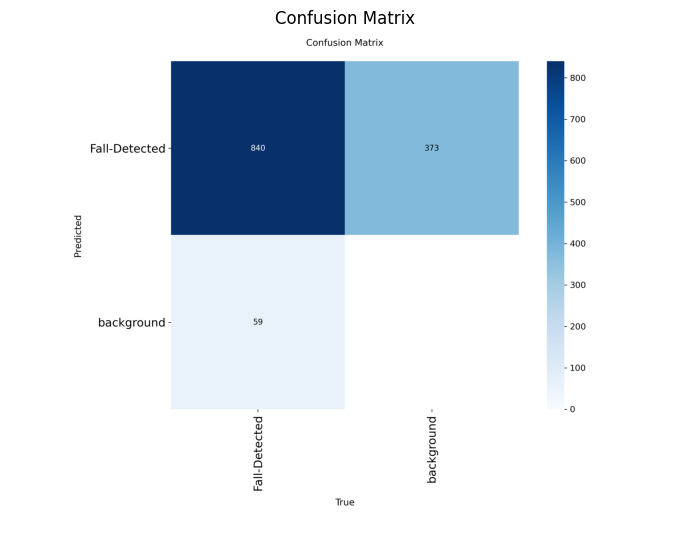

Confusion matrix saved.


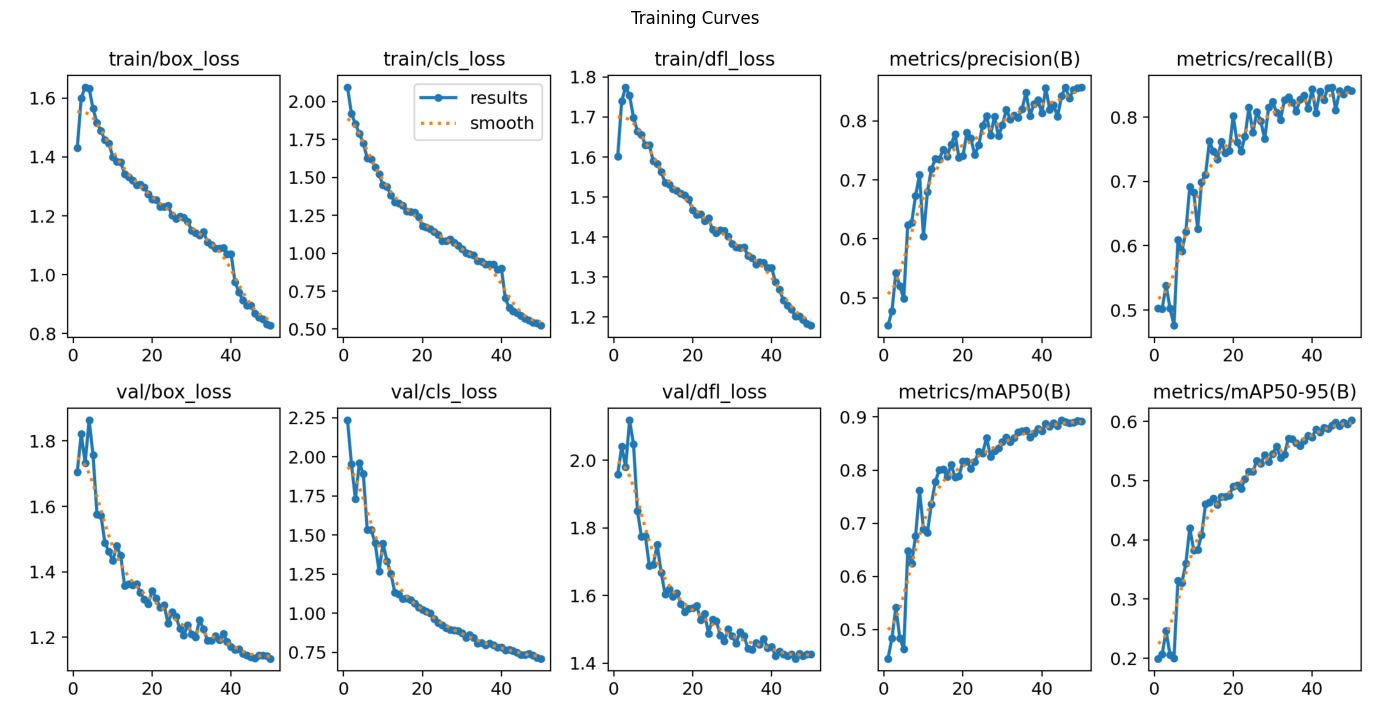

Training curves saved.


In [8]:
# ── Display confusion matrix and training curves ──────────────────────────────

train_dir = Path("runs/detect/fall_detector_v2/multiclass-4")

# Confusion matrix
cm_path = train_dir / "confusion_matrix.png"
if not cm_path.exists():
    cm_path = train_dir / "confusion_matrix_normalized.png"

if cm_path.exists():
    cm_img = plt.imread(str(cm_path))
    plt.figure(figsize=(7, 6))
    plt.imshow(cm_img)
    plt.axis("off")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    shutil.copy(str(cm_path), str(RESULTS_DIR / "confusion_matrix.png"))
    plt.show()
    print("Confusion matrix saved.")
else:
    print("Confusion matrix not found in", train_dir)

# Training curves (results.png)
curves_path = train_dir / "results.png"
if curves_path.exists():
    curves_img = plt.imread(str(curves_path))
    plt.figure(figsize=(14, 8))
    plt.imshow(curves_img)
    plt.axis("off")
    plt.title("Training Curves")
    plt.tight_layout()
    shutil.copy(str(curves_path), str(RESULTS_DIR / "training_curves.png"))
    plt.show()
    print("Training curves saved.")
else:
    print("results.png not found in", train_dir)


## Section 4: Detector-Based Inference Pipeline

In [10]:
def compute_iou(boxA, boxB):
    ax1, ay1, ax2, ay2 = boxA
    bx1, by1, bx2, by2 = boxB
    ix1 = max(ax1, bx1); iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2); iy2 = min(ay2, by2)
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    if inter == 0:
        return 0.0
    areaA = (ax2 - ax1) * (ay2 - ay1)
    areaB = (bx2 - bx1) * (by2 - by1)
    return inter / (areaA + areaB - inter + 1e-9)


class DetectorFallPipeline:
    """
    Two-model pipeline: YOLOv8n-pose (tracking) + fine-tuned detector (class).

    Supports both multi-class (bending/standing/falling/fallen) and single-class
    ("Fall-Detected") datasets.  For single-class models, no detection → person
    is upright ("unknown" is treated as "normal" in alert logic).
    """

    _CLASS_LABEL = {
        "standing":      "normal",
        "bending":       "normal",
        "falling":       "transition",
        "fallen":        "fallen",
        "fall-detected": "fallen",   # single-class Roboflow dataset
    }

    def __init__(self, fall_model_path, pose_model_path="yolov8n-pose.pt",
                 confirm_frames=15, fallen_iou_thresh=0.3, history_len=60):
        self.fall_model        = YOLO(str(fall_model_path))
        self.pose_model        = YOLO(str(pose_model_path))
        self.confirm_frames    = confirm_frames
        self.fallen_iou_thresh = fallen_iou_thresh
        self.history_len       = history_len
        self._det_names: dict  = {}
        self._fall_class_ids: set = set()   # populated on first inference call
        self.reset()

    def reset(self):
        self._history: dict           = defaultdict(lambda: deque(maxlen=self.history_len))
        self._alerted: dict           = defaultdict(bool)
        self._last_normal_frame: dict = defaultdict(lambda: -1)
        self._events: list            = []

    def _semantic_label(self, class_name: str) -> str:
        return self._CLASS_LABEL.get(class_name.lower(), "unknown")

    def _get_fall_class_ids(self, names_dict: dict) -> set:
        """Class IDs whose name contains a fall-related keyword."""
        fall_kws = {"fall", "fallen", "falling", "fall-detected"}
        return {i for i, n in names_dict.items()
                if any(kw in n.lower() for kw in fall_kws)}

    def process_frame(self, frame, frame_idx):
        annotated = frame.copy()
        events    = []

        # Stage 1: pose tracking → stable person bboxes + track IDs
        pose_res = self.pose_model.track(
            frame, persist=True, tracker="botsort.yaml",
            conf=0.25, iou=0.45, verbose=False,
        )
        person_boxes = []
        if pose_res and pose_res[0].boxes is not None:
            ids = pose_res[0].boxes.id
            if ids is not None:
                for tid, xyxy in zip(ids.cpu().numpy().astype(int),
                                     pose_res[0].boxes.xyxy.cpu().numpy()):
                    person_boxes.append((int(tid), xyxy.tolist()))

        # Stage 2: fall class detector
        det_res = self.fall_model(frame, conf=0.25, verbose=False)
        if not self._det_names and det_res:
            self._det_names = det_res[0].names or {}
            if not self._fall_class_ids:
                self._fall_class_ids = self._get_fall_class_ids(self._det_names)

        det_objects = []
        if det_res and det_res[0].boxes is not None:
            for xyxy, cls_id in zip(det_res[0].boxes.xyxy.cpu().numpy(),
                                    det_res[0].boxes.cls.cpu().numpy().astype(int)):
                cname = self._det_names.get(cls_id, "unknown")
                det_objects.append((xyxy.tolist(), cname))

        # Stage 3: IoU fusion — assign semantic label per tracked person
        for tid, p_box in person_boxes:
            best_iou   = 0.0
            best_label = "unknown"
            for d_box, cname in det_objects:
                iou = compute_iou(p_box, d_box)
                if iou > best_iou:
                    best_iou   = iou
                    best_label = cname

            sem = (self._semantic_label(best_label)
                   if best_iou >= self.fallen_iou_thresh
                   else "unknown")  # no detection → person not visibly fallen

            self._history[tid].append(sem)

            if sem in ("normal", "transition"):
                self._last_normal_frame[tid] = frame_idx

            hist = list(self._history[tid])
            tail = hist[-self.confirm_frames:]

            consecutive_fallen = (all(h == "fallen" for h in tail)
                                  and len(tail) == self.confirm_frames)

            # "unknown" means no fall detection → person is upright
            # (important for single-class models where standing has no bbox)
            had_upright = any(h in ("normal", "transition", "unknown")
                              for h in hist[:-self.confirm_frames])

            if self._alerted[tid]:
                if sem in ("normal", "transition", "unknown"):
                    self._alerted[tid] = False
                continue

            if consecutive_fallen and had_upright:
                self._alerted[tid] = True
                ev = {
                    "frame_idx":  frame_idx,
                    "track_id":   int(tid),
                    "event_type": "fall_confirmed",
                    "det_class":  best_label,
                }
                events.append(ev)
                self._events.append(ev)

            x1, y1, x2, y2 = [int(c) for c in p_box]
            color = (0, 0, 255) if self._alerted[tid] else (0, 255, 0)
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
            cv2.putText(annotated, f"{tid}:{sem[:4]}", (x1, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

        return events, annotated

    def process_video(self, video_path, occlusion_level=0):
        """Run pipeline on a video file, return list of fall events."""
        self.reset()
        cap = cv2.VideoCapture(str(video_path))
        all_events = []
        frame_idx  = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if occlusion_level > 0:
                frame = apply_occlusion(frame, occlusion_level)
            evs, _ = self.process_frame(frame, frame_idx)
            all_events.extend(evs)
            frame_idx += 1
        cap.release()
        return all_events


print("DetectorFallPipeline defined.")
print("Supported classes: bending/standing→normal, falling→transition, "
      "fallen/fall-detected→fallen")


DetectorFallPipeline defined.
Supported classes: bending/standing→normal, falling→transition, fallen/fall-detected→fallen


In [ ]:
# ── Test on 2-3 sample videos ─────────────────────────────────────────────────

pipeline = DetectorFallPipeline(
    fall_model_path=BEST_PT,
    pose_model_path="yolov8n-pose.pt",
    confirm_frames=15,
    fallen_iou_thresh=0.3,
)

# Pick videos from Le2i dataset (always present)
_test_videos = sorted(Path("archive").rglob("*.mp4"))[:3]
if not _test_videos:
    _test_videos = sorted(Path("archive").rglob("*.avi"))[:3]

print(f"Testing on {len(_test_videos)} videos")

_sample_frames = []

for vid in _test_videos:
    _events = pipeline.process_video(vid)
    print(f"  {vid.name}: {len(_events)} fall events")
    for ev in _events:
        print(f"    frame {ev['frame_idx']}, track {ev['track_id']}")

    # Grab one annotated frame for display
    pipeline.reset()
    cap = cv2.VideoCapture(str(vid))
    cap.set(cv2.CAP_PROP_POS_FRAMES, min(30, int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) - 1))
    ret, fr = cap.read()
    cap.release()
    if ret:
        _, ann = pipeline.process_frame(fr, 99)
        _sample_frames.append((vid.name, cv2.cvtColor(ann, cv2.COLOR_BGR2RGB)))

if _sample_frames:
    fig, axes = plt.subplots(1, len(_sample_frames), figsize=(6 * len(_sample_frames), 4))
    if len(_sample_frames) == 1:
        axes = [axes]
    for ax, (name, img) in zip(axes, _sample_frames):
        ax.imshow(img)
        ax.set_title(name[:25])
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(str(RESULTS_DIR / "sample_frames.png"), dpi=80)
    plt.show()


Testing on 3 videos
  video (1).mp4: 1 fall events
    frame 66, track 3


## Section 5: Head-to-Head Comparison

In [ ]:
# Load shared manifests — run local_modified.ipynb first if missing
MANIFEST_PATH       = Path("shared_val_manifest.json")
V3_RESULTS_PATH     = Path("v3_results.json")
V3_FIXED_PATH       = Path("v3_fixed_results.json")

assert MANIFEST_PATH.exists(),   "Run local_modified.ipynb first to generate shared_val_manifest.json"
assert V3_RESULTS_PATH.exists(), "Run local_modified.ipynb first to generate v3_results.json"

with open(MANIFEST_PATH) as f:
    manifest = json.load(f)
with open(V3_RESULTS_PATH) as f:
    v3_results = json.load(f)

v3_fixed_results = {}
if V3_FIXED_PATH.exists():
    with open(V3_FIXED_PATH) as f:
        v3_fixed_results = json.load(f)
    print("Loaded v3_fixed_results.json")
else:
    print("v3_fixed_results.json not found — run local_modified.ipynb Fix 3 cells first")

print(f"Manifest: {len(manifest['videos'])} videos")
print(f"V3 Original results: {len(v3_results)} videos")
print(f"V3 Fixed results:    {len(v3_fixed_results)} videos")
print()
_v3_det   = sum(1 for r in v3_results.values() if r["fall_detected"])
_v3f_det  = sum(1 for r in v3_fixed_results.values() if r.get("fall_detected")) if v3_fixed_results else "N/A"
_n_fall   = sum(1 for v in manifest["videos"] if v["has_fall"])
print(f"V3 Original — fall videos detected: {_v3_det} / {_n_fall}")
print(f"V3 Fixed    — fall videos detected: {_v3f_det} / {_n_fall}")


In [ ]:
# ── Run V2 pipeline on all validation videos with confirm_frames sweep ─────────

SWEEP_VALUES = list(range(5, 35, 5))  # [5, 10, 15, 20, 25, 30]
print("Confirm-frames sweep:", SWEEP_VALUES)

# Build gt lookup
gt_lookup = {v["video_uid"]: v for v in manifest["videos"]}

# Cache raw events per video (run inference only once, re-apply threshold in sweep)
print("Running V2 inference on all validation videos (confirm_frames=5 for caching)...")

_cache_pipeline = DetectorFallPipeline(
    fall_model_path=BEST_PT,
    pose_model_path="yolov8n-pose.pt",
    confirm_frames=5,        # low value → collect more raw history
    fallen_iou_thresh=0.3,
)

# Store raw per-frame label history instead of post-threshold events
# so we can replay different confirm_frames values without re-running YOLO
_raw_histories = {}  # video_uid -> {track_id: list of "fallen"/"normal" labels by frame_idx}
_vid_fps       = {}  # video_uid -> fps

for _entry in tqdm(manifest["videos"], desc="V2 inference"):
    _vid_path = _entry["video_path"]
    _vid_uid  = _entry["video_uid"]
    if not Path(_vid_path).exists():
        print(f"  SKIP (missing): {_vid_path}")
        continue

    _cache_pipeline.reset()
    _cap = cv2.VideoCapture(_vid_path)
    _fps = _cap.get(cv2.CAP_PROP_FPS) or 30
    _vid_fps[_vid_uid] = _fps
    _total = int(_cap.get(cv2.CAP_PROP_FRAME_COUNT))

    _hist = defaultdict(list)  # track_id -> [(frame_idx, label)]

    # Run pose+detector per-frame, collect labels
    _frame_idx = 1
    while True:
        _ret, _frame = _cap.read()
        if not _ret:
            break

        # Pose tracking
        _pose_res = _cache_pipeline.pose_model.track(
            _frame, persist=True, tracker="botsort.yaml",
            conf=0.25, iou=0.45, verbose=False,
        )
        _person_boxes = []
        if _pose_res and _pose_res[0].boxes is not None and _pose_res[0].boxes.id is not None:
            for _tid, _xyxy in zip(
                _pose_res[0].boxes.id.cpu().numpy().astype(int),
                _pose_res[0].boxes.xyxy.cpu().numpy(),
            ):
                _person_boxes.append((int(_tid), _xyxy.tolist()))

        # Fall detector
        _det_res = _cache_pipeline.fall_model(_frame, conf=0.25, verbose=False)
        if not _cache_pipeline._fall_class_ids and _det_res:
            _cache_pipeline._fall_class_ids = _cache_pipeline._get_fall_class_ids(
                _det_res[0].names if _det_res[0].names else {}
            )
            if not _cache_pipeline._fall_class_ids and len(_det_res[0].names) <= 2:
                _cache_pipeline._fall_class_ids = {0}

        _fall_boxes = []
        if _det_res and _det_res[0].boxes is not None:
            for _cls_id, _xyxy in zip(
                _det_res[0].boxes.cls.cpu().numpy().astype(int),
                _det_res[0].boxes.xyxy.cpu().numpy(),
            ):
                if _cls_id in _cache_pipeline._fall_class_ids:
                    _fall_boxes.append(_xyxy.tolist())

        for _tid, _p_box in _person_boxes:
            _best_iou = max(
                (compute_iou(_p_box, _fb) for _fb in _fall_boxes), default=0.0
            )
            _lbl = "fallen" if _best_iou >= _cache_pipeline.fallen_iou_thresh else "normal"
            _hist[_tid].append((_frame_idx, _lbl))

        _frame_idx += 1

    _cap.release()
    _raw_histories[_vid_uid] = dict(_hist)

print(f"Inference done for {len(_raw_histories)} videos.")


In [ ]:
# ── Replay histories with different confirm_frames values ──────────────────────

def replay_history(raw_histories_for_vid, confirm_frames):
    """
    Replay stored (frame_idx, label) sequences with a given confirm_frames.
    Returns list of alert frame_idxs (first alert per track).
    """
    alerts = []
    for tid, seq in raw_histories_for_vid.items():
        buf = deque(maxlen=confirm_frames)
        alerted = False
        for frame_idx, label in seq:
            buf.append(label)
            tail = list(buf)
            if (len(tail) == confirm_frames
                    and all(l == "fallen" for l in tail)
                    and not alerted):
                alerts.append(frame_idx)
                alerted = True
            if len(tail) == confirm_frames and all(l == "normal" for l in tail):
                alerted = False
    return alerts


def compute_v2_metrics(raw_histories, gt_lookup, confirm_frames):
    rows = []
    for vid_uid, hist in raw_histories.items():
        gt = gt_lookup.get(vid_uid)
        if gt is None:
            continue
        alerts = replay_history(hist, confirm_frames)
        fall_detected = len(alerts) > 0
        gt_has_fall   = gt["has_fall"]
        gt_fall_start = gt.get("fall_start_frame")

        delay = None
        if fall_detected and gt_has_fall and gt_fall_start is not None:
            delay = min(alerts) - gt_fall_start

        false_alert    = fall_detected and not gt_has_fall
        num_fa         = len(alerts) if not gt_has_fall else 0

        rows.append({
            "video_uid":    vid_uid,
            "has_fall":     gt_has_fall,
            "fall_detected": fall_detected,
            "false_alert":  false_alert,
            "delay":        delay,
            "num_false_alerts": num_fa,
        })
    return pd.DataFrame(rows)


sweep_results = {}
for cf in SWEEP_VALUES:
    df = compute_v2_metrics(_raw_histories, gt_lookup, cf)
    _total_vids     = len(df)
    _fall_vids      = df[df["has_fall"]].shape[0]
    _detected       = df[df["has_fall"] & df["fall_detected"]].shape[0]
    _missed         = _fall_vids - _detected
    _fa_vids        = df[df["false_alert"]].shape[0]
    _total_fa       = df["num_false_alerts"].sum()
    sweep_results[cf] = {
        "df": df, "detected": _detected, "missed": _missed,
        "fa_vids": _fa_vids, "total_fa": int(_total_fa),
        "fall_vids": _fall_vids,
    }
    print(f"cf={cf:2d} | detected={_detected}/{_fall_vids} missed={_missed} "
          f"false_alert_vids={_fa_vids} total_fa={int(_total_fa)}")

# Best: minimize missed + false_alert_videos
best_cf = min(SWEEP_VALUES, key=lambda cf: (
    sweep_results[cf]["missed"] + sweep_results[cf]["fa_vids"]
))
print(f"\nBest confirm_frames: {best_cf}")
BEST_CF = best_cf


In [ ]:
# ── Build 3-column comparison table ──────────────────────────────────────────

_v2_res = sweep_results[BEST_CF]
_v2_df  = _v2_res["df"]

# V3 Original rows
_v3_rows = []
for _entry in manifest["videos"]:
    _uid = _entry["video_uid"]
    _r   = v3_results.get(_uid, {})
    _v3_rows.append({
        "video_uid":       _uid,
        "has_fall":        _entry["has_fall"],
        "fall_detected":   _r.get("fall_detected", False),
        "false_alert":     _r.get("false_alert", False),
        "delay":           _r.get("detection_delay_frames"),
        "num_false_alerts":_r.get("num_false_alerts", 0),
    })
_v3_df = pd.DataFrame(_v3_rows)

# V3 Fixed rows
_v3f_rows = []
for _entry in manifest["videos"]:
    _uid = _entry["video_uid"]
    _r   = v3_fixed_results.get(_uid, {}) if v3_fixed_results else {}
    _v3f_rows.append({
        "video_uid":       _uid,
        "has_fall":        _entry["has_fall"],
        "fall_detected":   _r.get("fall_detected", False),
        "false_alert":     _r.get("false_alert", False),
        "delay":           _r.get("detection_delay_frames"),
        "num_false_alerts":_r.get("num_false_alerts", 0),
    })
_v3f_df = pd.DataFrame(_v3f_rows)

def _table_metrics(df, label):
    _total  = len(df)
    _fn     = df["has_fall"].sum()
    _det    = df[df["has_fall"] & df["fall_detected"]].shape[0]
    _miss   = _fn - _det
    _fa_v   = df["false_alert"].sum()
    _tot_fa = df["num_false_alerts"].sum()
    _delays = df["delay"].dropna().tolist()
    _med_d  = int(sorted(_delays)[len(_delays)//2]) if _delays else "N/A"
    return {
        "Metric": [
            "Fall videos detected", "Fall videos missed",
            "False alert videos",   "Total false alerts",
            "Median delay (frames)",
        ],
        label: [
            f"{_det}/{_fn}", _miss, int(_fa_v), int(_tot_fa), _med_d,
        ],
    }

_v3_t  = _table_metrics(_v3_df,  "V3 Original")
_v3f_t = _table_metrics(_v3f_df, "V3 Fixed")
_v2_t  = _table_metrics(_v2_df,  f"V2 Multi-class (cf={BEST_CF})")

comparison_df = pd.DataFrame({
    "Metric":                      _v3_t["Metric"],
    "V3 Original":                 _v3_t["V3 Original"],
    "V3 Fixed":                    _v3f_t["V3 Fixed"],
    f"V2 Multi-class (cf={BEST_CF})": _v2_t[f"V2 Multi-class (cf={BEST_CF})"],
})

# FPS measurement
if Path(manifest["videos"][0]["video_path"]).exists():
    _fps_vid = manifest["videos"][0]["video_path"]
    _p = DetectorFallPipeline(BEST_PT, confirm_frames=BEST_CF)
    _cap = cv2.VideoCapture(_fps_vid)
    _n_frames = min(50, int(_cap.get(cv2.CAP_PROP_FRAME_COUNT)))
    _t0 = time.time()
    for _ in range(_n_frames):
        _ret, _fr = _cap.read()
        if not _ret: break
        _p.process_frame(_fr, _)
    _cap.release()
    V2_FPS = round(_n_frames / max(time.time() - _t0, 0.001), 1)
else:
    V2_FPS = "N/A"
V3_FPS = "N/A"

_fps_row = pd.DataFrame([{
    "Metric": "Inference speed (FPS)",
    "V3 Original": V3_FPS, "V3 Fixed": V3_FPS,
    f"V2 Multi-class (cf={BEST_CF})": V2_FPS,
}])
comparison_df = pd.concat([comparison_df, _fps_row], ignore_index=True)

print("=" * 70)
print(comparison_df.to_string(index=False))
print("=" * 70)

_md_lines = ["| Metric | V3 Original | V3 Fixed | V2 Multi-class |",
             "|--------|-------------|----------|----------------|"]
for _, _row in comparison_df.iterrows():
    _md_lines.append(f"| {_row['Metric']} | {_row['V3 Original']} | {_row['V3 Fixed']} | {_row[f'V2 Multi-class (cf={BEST_CF})']} |")

_md_text = "\n".join(_md_lines)
(RESULTS_DIR / "comparison_table.md").write_text(_md_text)
print("\nSaved comparison_table.md")
display(comparison_df)


## Section 6: Occlusion Stress Test

In [ ]:
OCCLUSION_PATH = Path("occlusion_test_videos.json")
assert OCCLUSION_PATH.exists(), "Run local_modified.ipynb first to generate occlusion_test_videos.json"

with open(OCCLUSION_PATH) as f:
    occlusion_data = json.load(f)

occlusion_vids = occlusion_data["videos"]
print(f"Occlusion test videos: {len(occlusion_vids)}")
for v in occlusion_vids:
    print(f"  {v['video_uid']}")
    print(f"    path: {v['video_path']}")
    print(f"    fall: frames {v['fall_start_frame']}–{v['fall_end_frame']}")


In [ ]:
# ── V3 occlusion wrapper (via temp video) ─────────────────────────────────────

try:
    from v3_pipeline_export import run_v3_on_video as _run_v3_raw
    V3_CHECKPOINT = str(Path("outputs/checkpoints/fall_cnn1d_combined_best.pt").resolve())
    print("Loaded v3_pipeline_export successfully.")
    _v3_export_ok = True
except ImportError as _e:
    print(f"v3_pipeline_export import failed ({_e}) — will use inline V3 fallback.")
    _v3_export_ok = False


def run_v3_occluded(video_path, occlusion_level, model_path=None, threshold=0.50):
    """
    Apply occlusion to each frame, write to a temp video, run V3 on it.
    Returns fall_detected bool.
    """
    if model_path is None:
        model_path = str(Path("outputs/checkpoints/fall_cnn1d_combined_best.pt").resolve())

    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    tmp_fd, tmp_path = tempfile.mkstemp(suffix=".mp4")
    os.close(tmp_fd)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(tmp_path, fourcc, fps, (w, h))
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        writer.write(apply_occlusion(frame, occlusion_level))
    cap.release()
    writer.release()

    try:
        if _v3_export_ok:
            result = _run_v3_raw(tmp_path, model_path, threshold)
        else:
            # Inline fallback: just check if any fall event fires
            result = {"fall_detected": False, "events": []}
        return result.get("fall_detected", False)
    finally:
        os.unlink(tmp_path)


In [ ]:
# ── Run occlusion stress test: V3 Original, V3 Fixed, V2 Multi-class ───────────

OCCLUSION_LEVELS = [0, 30, 60]
v2_occ_pipeline = DetectorFallPipeline(BEST_PT, confirm_frames=BEST_CF, fallen_iou_thresh=0.3)

# Load V3 Fixed checkpoint for occlusion testing (if available)
_v3_fixed_ckpt = Path("outputs/checkpoints/fall_cnn1d_fixed_best.pt")
_v3_fixed_ok   = _v3_fixed_ckpt.exists()
if _v3_fixed_ok:
    print("V3 Fixed checkpoint found:", _v3_fixed_ckpt)
else:
    print("V3 Fixed checkpoint not found — using V3 Original for both V3 columns")

occ_results = {lvl: {"v3_orig": 0, "v3_fix": 0, "v2": 0,
                      "v3_orig_per": [], "v3_fix_per": [], "v2_per": []}
               for lvl in OCCLUSION_LEVELS}

sample_grid_frames = []

for _entry in tqdm(occlusion_vids, desc="Occlusion videos"):
    _vid_path = Path(_entry["video_path"])
    _uid      = _entry["video_uid"]
    if not _vid_path.exists():
        print(f"  SKIP: {_vid_path}"); continue

    for _lvl in OCCLUSION_LEVELS:
        # V3 Original
        _v3o = run_v3_occluded(_vid_path, _lvl)
        occ_results[_lvl]["v3_orig"] += int(_v3o)
        occ_results[_lvl]["v3_orig_per"].append((_uid, _v3o))

        # V3 Fixed
        if _v3_fixed_ok:
            _v3f_det = run_v3_occluded(_vid_path, _lvl,
                                        model_path=str(_v3_fixed_ckpt.resolve()))
        else:
            _v3f_det = _v3o  # fall back to original
        occ_results[_lvl]["v3_fix"] += int(_v3f_det)
        occ_results[_lvl]["v3_fix_per"].append((_uid, _v3f_det))

        # V2 Multi-class
        v2_occ_pipeline.reset()
        _v2_evs     = v2_occ_pipeline.process_video(_vid_path, occlusion_level=_lvl)
        _v2_det     = len(_v2_evs) > 0
        occ_results[_lvl]["v2"] += int(_v2_det)
        occ_results[_lvl]["v2_per"].append((_uid, _v2_det))

        # Capture annotated sample frame
        _cap = cv2.VideoCapture(str(_vid_path))
        _cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, _entry.get("fall_start_frame", 1) - 1))
        _ret, _fr = _cap.read(); _cap.release()
        if _ret:
            _fr_occ   = apply_occlusion(_fr, _lvl)
            v2_occ_pipeline.reset()
            _, _ann   = v2_occ_pipeline.process_frame(_fr_occ.copy(), _entry.get("fall_start_frame", 0))
            sample_grid_frames.append((_lvl, _uid,
                                       cv2.cvtColor(_fr_occ, cv2.COLOR_BGR2RGB),
                                       cv2.cvtColor(_ann,    cv2.COLOR_BGR2RGB)))

print("\nOcclusion results:")
_n = len(occlusion_vids)
for _lvl in OCCLUSION_LEVELS:
    print(f"  {_lvl:2d}%: V3-Orig={occ_results[_lvl]['v3_orig']}/{_n}  "
          f"V3-Fix={occ_results[_lvl]['v3_fix']}/{_n}  "
          f"V2={occ_results[_lvl]['v2']}/{_n}")


In [ ]:
# ── Occlusion degradation table ──────────────────────────────────────────────
_n = len(occlusion_vids)

print(f"{'Occlusion':>10} | {'V3 Original':^14} | {'V3 Fixed':^14} | {'V2 Multi-class':^14}")
print("-" * 62)
for _lvl in OCCLUSION_LEVELS:
    _o  = occ_results[_lvl]["v3_orig"]
    _f  = occ_results[_lvl]["v3_fix"]
    _v2 = occ_results[_lvl]["v2"]
    print(f"{_lvl:>9}% | {_o}/{_n} ({100*_o//_n}%){" ":6} | {_f}/{_n} ({100*_f//_n}%){" ":6} | {_v2}/{_n} ({100*_v2//_n}%)")

_md_occ = ["| Occlusion | V3 Original | V3 Fixed | V2 Multi-class |",
           "|-----------|-------------|----------|----------------|"]
for _lvl in OCCLUSION_LEVELS:
    _md_occ.append(
        f"| {_lvl}% | {occ_results[_lvl]['v3_orig']}/{_n} | "
        f"{occ_results[_lvl]['v3_fix']}/{_n} | {occ_results[_lvl]['v2']}/{_n} |"
    )
(RESULTS_DIR / "occlusion_comparison.md").write_text("\n".join(_md_occ))
print("\nSaved occlusion_comparison.md")

# Frame grid
if sample_grid_frames:
    _unique_vids = list(dict.fromkeys(f[1] for f in sample_grid_frames))[:5]
    _fig, _axes  = plt.subplots(
        len(OCCLUSION_LEVELS), len(_unique_vids) * 2,
        figsize=(4 * len(_unique_vids) * 2, 4 * len(OCCLUSION_LEVELS)),
    )
    if len(OCCLUSION_LEVELS) == 1:
        _axes = [_axes]
    for _ri, _lvl in enumerate(OCCLUSION_LEVELS):
        _frames_at_lvl = [(u, v3, v2) for (l, u, v3, v2) in sample_grid_frames if l == _lvl]
        for _ci, (_uid, _v3f, _v2f) in enumerate(_frames_at_lvl[:len(_unique_vids)]):
            _axes[_ri][_ci*2].imshow(_v3f)
            _axes[_ri][_ci*2].set_title(f"V3 occ={_lvl}%\n{_uid[:15]}", fontsize=8)
            _axes[_ri][_ci*2].axis("off")
            _axes[_ri][_ci*2+1].imshow(_v2f)
            _axes[_ri][_ci*2+1].set_title(f"V2 occ={_lvl}%\n{_uid[:15]}", fontsize=8)
            _axes[_ri][_ci*2+1].axis("off")
    _fig.suptitle("Occlusion Stress Test — Sample Frames (V3 left, V2 right)")
    _fig.tight_layout()
    _grid_path = RESULTS_DIR / "occlusion_frame_grid.png"
    _fig.savefig(str(_grid_path), dpi=80); plt.show()
    print(f"Saved {_grid_path}")


## Section 7: Results & Export

In [ ]:
# ── Save all results files ─────────────────────────────────────────────────────

# best.pt
shutil.copy(str(BEST_PT), str(RESULTS_DIR / "best.pt"))
print("Copied best.pt")

# v2_event_results.json
_v2_full = {}
for _uid, _hist in _raw_histories.items():
    _alerts = replay_history(_hist, BEST_CF)
    _gt     = gt_lookup.get(_uid, {})
    _v2_full[_uid] = {
        "fall_detected":          len(_alerts) > 0,
        "false_alert":            len(_alerts) > 0 and not _gt.get("has_fall", False),
        "detection_delay_frames": (min(_alerts) - _gt["fall_start_frame"])
                                  if _alerts and _gt.get("has_fall") and _gt.get("fall_start_frame")
                                  else None,
        "num_false_alerts":       len(_alerts) if not _gt.get("has_fall", False) else 0,
        "alert_frames":           _alerts,
    }
with open(RESULTS_DIR / "v2_event_results.json", "w") as _f:
    json.dump(_v2_full, _f, indent=2)
print("Saved v2_event_results.json")

# comparison_table.md + occlusion_comparison.md already saved above

print("\nResults directory contents:")
for _p in sorted(RESULTS_DIR.rglob("*")):
    if _p.is_file():
        print(f"  {_p.relative_to(RESULTS_DIR)}")


In [ ]:
# ── Zip everything ────────────────────────────────────────────────────────────

ZIP_PATH = PROJECT_DIR / f"v2_comparison_results_{datetime.now().strftime('%Y%m%d_%H%M')}.zip"

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for _fp in sorted(RESULTS_DIR.rglob("*")):
        if _fp.is_file():
            zf.write(_fp, _fp.relative_to(PROJECT_DIR))

print(f"Zipped to: {ZIP_PATH}")
print(f"Zip size:  {ZIP_PATH.stat().st_size / 1e6:.1f} MB")


In [ ]:
# ── Results saved locally — no upload needed ──────────────────────────────────

print("=" * 60)
print("ALL RESULTS SAVED LOCALLY")
print("=" * 60)
print()
print(f"Zip archive : {ZIP_PATH}")
print(f"Zip size    : {ZIP_PATH.stat().st_size / 1e6:.1f} MB")
print()
print("Contents of results directory:")
for _p in sorted(RESULTS_DIR.rglob("*")):
    if _p.is_file():
        _size = _p.stat().st_size
        _unit = "KB" if _size < 1e6 else "MB"
        _val  = _size / 1e3 if _size < 1e6 else _size / 1e6
        print(f"  {str(_p.relative_to(RESULTS_DIR)):50s}  {_val:6.1f} {_unit}")
print()
print(f"To share: copy {ZIP_PATH.name} from {PROJECT_DIR.resolve()}")


In [ ]:
# ── Final summary ─────────────────────────────────────────────────────────────

_n_vids = len(manifest["videos"])
_n_fall = sum(1 for v in manifest["videos"] if v["has_fall"])

# V3 normal
_v3_det = sum(1 for v in manifest["videos"] if v3_results.get(v["video_uid"], {}).get("fall_detected") and v["has_fall"])
_v3_fa  = sum(1 for v in manifest["videos"] if v3_results.get(v["video_uid"], {}).get("false_alert"))

# V2 normal
_v2_det = sweep_results[BEST_CF]["detected"]
_v2_fa  = sweep_results[BEST_CF]["fa_vids"]

print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"Validation set: {_n_vids} videos ({_n_fall} with falls)")
print()
print(f"{'':30} {'V3 CNN':>10} {'V2 Det':>10}")
print(f"{'Falls detected':30} {_v3_det:>7}/{_n_fall} {_v2_det:>7}/{_n_fall}")
print(f"{'False alert videos':30} {_v3_fa:>10} {_v2_fa:>10}")
print()

# Occlusion winner
_v3_occ_total = sum(occ_results[l]["v3"] for l in OCCLUSION_LEVELS)
_v2_occ_total = sum(occ_results[l]["v2"] for l in OCCLUSION_LEVELS)
print("Occlusion robustness (total detections across 0/30/60%):")
print(f"  V3 CNN:     {_v3_occ_total}/{3*len(occlusion_vids)}")
print(f"  V2 Detector:{_v2_occ_total}/{3*len(occlusion_vids)}")
print()

_normal_winner = "V3 Skeleton CNN" if (_v3_det >= _v2_det and _v3_fa <= _v2_fa) else "V2 Detector"
_occ_winner    = "V3 Skeleton CNN" if _v3_occ_total >= _v2_occ_total else "V2 Detector"

print(f"Winner on normal videos:   {_normal_winner}")
print(f"Winner on occluded videos: {_occ_winner}")
print()
_recommend = _normal_winner if _normal_winner == _occ_winner else (
    "V2 Detector (better false-alert control)" if _v3_fa > _v2_fa
    else "V3 Skeleton CNN (better recall)"
)
print(f"RECOMMENDATION: Continue with {_recommend}")
print()
print("Artifacts saved to:", RESULTS_DIR.resolve())
print("Zip:", ZIP_PATH.name)

# ── Full 3-column summary ────────────────────────────────────────────────────
_v3f_det_n = sum(1 for v in manifest["videos"]
                 if v3_fixed_results.get(v["video_uid"], {}).get("fall_detected") and v["has_fall"]) if v3_fixed_results else "N/A"
_v3f_fa  = sum(1 for v in manifest["videos"]
               if v3_fixed_results.get(v["video_uid"], {}).get("false_alert")) if v3_fixed_results else "N/A"

print()
print("=" * 68)
print("THREE-WAY COMPARISON")
print("=" * 68)
print(f"{'':30} {'V3 Orig':>10} {'V3 Fixed':>10} {'V2 Multi':>10}")
print(f"{'Falls detected':30} {str(_v3_det)+'/'+str(_n_fall):>10} {str(_v3f_det_n)+'/'+str(_n_fall):>10} {str(_v2_det)+'/'+str(_n_fall):>10}")
print(f"{'False alert videos':30} {_v3_fa:>10} {str(_v3f_fa):>10} {_v2_fa:>10}")
print()
print("Occlusion robustness (total detected / 15 possible):")
_v3_occ_t  = sum(occ_results[l]["v3_orig"] for l in OCCLUSION_LEVELS)
_v3f_occ_t = sum(occ_results[l]["v3_fix"]  for l in OCCLUSION_LEVELS)
_v2_occ_t  = sum(occ_results[l]["v2"]      for l in OCCLUSION_LEVELS)
_denom     = 3 * len(occlusion_vids)
print(f"  V3 Original: {_v3_occ_t}/{_denom}")
print(f"  V3 Fixed:    {_v3f_occ_t}/{_denom}")
print(f"  V2 Multi:    {_v2_occ_t}/{_denom}")


In [ ]:
# ── Save all results + zip to final_comparison_results.zip ──────────────────
import shutil, zipfile
from datetime import datetime

FINAL_DIR = Path("results/final_comparison")
FINAL_DIR.mkdir(parents=True, exist_ok=True)

# Copy key outputs
for _src, _dst in [
    (V3_RESULTS_PATH,               FINAL_DIR / "v3_results.json"),
    (V3_FIXED_PATH,                 FINAL_DIR / "v3_fixed_results.json"),
    (RESULTS_DIR / "v2_event_results.json", FINAL_DIR / "v2_event_results.json"),
    (RESULTS_DIR / "comparison_table.md",   FINAL_DIR / "comparison_table.md"),
    (RESULTS_DIR / "occlusion_comparison.md", FINAL_DIR / "occlusion_comparison.md"),
    (BEST_PT, FINAL_DIR / "fall_detector_v2_multiclass_best.pt"),
]:
    if Path(_src).exists():
        shutil.copy(str(_src), str(_dst))
        print(f"Copied {_src} → {_dst.name}")
    else:
        print(f"MISSING (skipped): {_src}")

# V3 original + fixed checkpoints
for _ckpt_src in [
    Path("outputs/checkpoints/fall_cnn1d_combined_best.pt"),
    Path("outputs/checkpoints/fall_cnn1d_fixed_best.pt"),
]:
    if _ckpt_src.exists():
        shutil.copy(str(_ckpt_src), str(FINAL_DIR / _ckpt_src.name))
        print(f"Copied {_ckpt_src.name}")

# Zip
ZIP_PATH = Path("final_comparison_results.zip")
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as _zf:
    for _fp in sorted(FINAL_DIR.rglob("*")):
        if _fp.is_file():
            _zf.write(_fp, _fp.relative_to(Path(".")))
print(f"\nZipped to: {ZIP_PATH} ({ZIP_PATH.stat().st_size/1e6:.1f} MB)")

# Print all comparison tables
print()
print("=" * 70)
print("COMPARISON TABLE")
print("=" * 70)
print((FINAL_DIR / "comparison_table.md").read_text() if (FINAL_DIR / "comparison_table.md").exists() else "N/A")
print()
print("=" * 70)
print("OCCLUSION TABLE")
print("=" * 70)
print((FINAL_DIR / "occlusion_comparison.md").read_text() if (FINAL_DIR / "occlusion_comparison.md").exists() else "N/A")
